# Customer Purchase Prediction & Marketing Optimization Using Machine Learning

## Business Problem
Companies often spend large budgets on marketing campaigns without knowing which customers are likely to respond. This leads to wasted resources and low conversion rates.

## Objective
To build a machine learning model that predicts which customers are likely to make a purchase, enabling more targeted and efficient marketing strategies.

In [1]:
# Basic
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# Load Dataset
df = pd.read_csv("marketing_campaign.csv", sep='\t')

# Display first 5 rows
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# Data Overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
# Dataset Shape
df.shape

(2240, 29)

In [5]:
# Statistical Summary
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [6]:
# Check Missing Values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
# Data Cleaning

# Fill missing values in Income using median
df['Income'] = df['Income'].fillna(df['Income'].median())

In [8]:
# Check if missing values are resolved
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [9]:
# Feature Engineering

# Create Age from Year_Birth
df['Age'] = 2026 - df['Year_Birth']

# Total Spending
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                           'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

# Total Purchases
df['Total_Purchases'] = df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)

In [10]:
# Check new features
df[['Age','Total_Spending','Total_Purchases']].describe()

,Age,Total_Spending,Total_Purchases
count,2240.000000,2240.000000,2240.000000
mean,57.194196,605.798214,12.537054
std,11.984069,602.249288,7.205741
min,30.000000,5.000000,0.000000
25%,49.000000,68.750000,6.000000
50%,56.000000,396.000000,12.000000
75%,67.000000,1045.500000,18.000000
max,133.000000,2525.000000,32.000000


In [11]:
# Target Variable
df['Target'] = df['Response']

In [12]:
# Select optimized features (business-driven)
X = df[[
    'Age',
    'Income',
    'Recency',
    'Total_Spending',
    'Total_Purchases',
    'NumWebVisitsMonth',
    'AcceptedCmp1'
]]

# Target variable
y = df['Target']

In [13]:
# Check dataset shape after encoding
X.shape

(2240, 7)

In [14]:
# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# Check shapes
X_train.shape, X_test.shape

((1792, 7), (448, 7))

In [16]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [17]:
# Train Logistic Regression model (fixed)
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
# Make predictions
y_pred_lr = lr.predict(X_test)

In [19]:
# Evaluate model
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8638392857142857


In [20]:
# Train Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',   #imbalance
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [21]:
rf.predict_proba(X_test[:5])

array([[0.6825235 , 0.3174765 ],
       [0.71924337, 0.28075663],
       [0.81236017, 0.18763983],
       [0.5144529 , 0.4855471 ],
       [0.73625053, 0.26374947]])

In [22]:
# Make predictions (Random Forest)
y_pred_rf = rf.predict(X_test)


In [23]:
# Evaluate model
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8660714285714286


In [24]:
# Train XGBoost model
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [25]:
# Make predictions (XGBoost)
y_pred_xgb = xgb.predict(X_test)

In [26]:
# Evaluate model
from sklearn.metrics import accuracy_score

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8660714285714286


In [27]:
# Model Comparison
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Logistic Regression: 0.8638392857142857
Random Forest: 0.8660714285714286
XGBoost: 0.8660714285714286


In [28]:
#Classification report
from sklearn.metrics import classification_report

print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.87      0.99      0.92       381
           1       0.69      0.16      0.27        67

    accuracy                           0.86       448
   macro avg       0.78      0.58      0.60       448
weighted avg       0.84      0.86      0.83       448

Random Forest Report:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       381
           1       0.57      0.43      0.49        67

    accuracy                           0.87       448
   macro avg       0.74      0.69      0.71       448
weighted avg       0.85      0.87      0.86       448

XGBoost Report:
               precision    recall  f1-score   support

           0       0.88      0.98      0.93       381
           1       0.65      0.22      0.33        67

    accuracy                           0.87       448
   macro avg       0.76      0.60      0.63       448
weigh

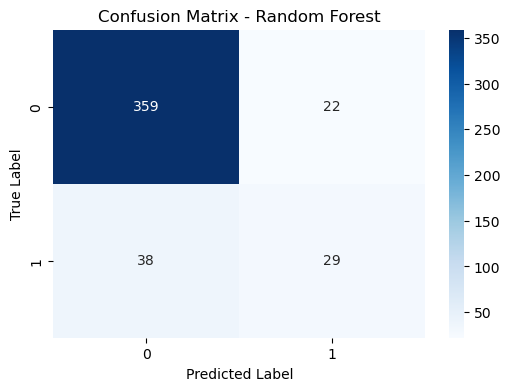

In [29]:
# Visualization - Confusion Matrix (Random Forest)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Confusion Matrix Interpretation (Random Forest)

The confusion matrix evaluates how well the model classifies customers into buyers (1) and non-buyers (0).

- **True Negatives (Top-left):** Customers correctly identified as non-buyers  
- **True Positives (Bottom-right):** Customers correctly identified as buyers  
- **False Positives (Top-right):** Customers incorrectly predicted as buyers  
- **False Negatives (Bottom-left):** Actual buyers who were missed by the model  

The model performs strongly in identifying non-buyers, as indicated by the high number of true negatives. However, it struggles to capture all potential buyers, as shown by the relatively high number of false negatives.

From a business perspective, false negatives are particularly critical because they represent missed revenue opportunities—customers who were likely to respond but were not targeted by marketing campaigns.

This highlights the need to improve recall for the positive class (buyers) to enhance marketing effectiveness.


## Model Interpretation

Three models were evaluated: Logistic Regression, Random Forest, and XGBoost.

Random Forest achieved the best overall performance (~87% accuracy), slightly outperforming Logistic Regression and XGBoost.

However, all models exhibited relatively low recall for class 1 (customers likely to purchase), indicating difficulty in identifying potential buyers.

This suggests that while the models are effective at identifying non-responders, they may fail to capture a significant portion of potential buyers, which has important business implications.

## Key Insights

- The dataset is imbalanced, which affects the model’s ability to detect buyers.
- Models tend to favor predicting non-buyers, leading to higher accuracy but lower recall for buyers.
- Improving recall for class 1 (buyers) is critical for maximizing marketing ROI.

## Limitations

- Class imbalance reduces the model’s effectiveness in identifying potential buyers.
- The models are biased toward predicting non-buyers, which can lead to missed opportunities.
- Recall for class 1 remains relatively low across all models.

## Future Improvements

- Apply resampling techniques such as SMOTE to address class imbalance.
- Perform hyperparameter tuning to optimize model performance.
- Explore advanced models such as LightGBM or CatBoost.
- Adjust classification thresholds to improve recall for potential buyers.
- Incorporate additional behavioral features to enhance predictive accuracy.

## Conclusion

Random Forest delivered the best overall performance among the evaluated models, achieving the highest accuracy.

Despite strong overall accuracy, all models struggled to identify potential buyers, as indicated by the relatively low recall for the positive class (class 1). This suggests that the models are more effective at identifying non-buyers than capturing customers likely to purchase.

From a business perspective, this limitation may lead to missed revenue opportunities, as potential buyers are not being effectively targeted.

Future improvements should focus on improving recall for the positive class through techniques such as handling class imbalance, hyperparameter tuning, and threshold optimization.

Overall, this project highlights the importance of aligning model performance with business goals when building predictive models for marketing optimization.

## Deployment: Generate Predictions for Business Use

Predictions were generated for all customers using the selected Random Forest model to support data-driven marketing decisions.

Each customer is assigned:

- A predicted outcome (likely to respond or not)  
- A probability score representing the likelihood of purchase  

Customers with high predicted probabilities (>0.7) are identified as potential targets for marketing campaigns, enabling more efficient allocation of marketing resources.

In addition, customers can be segmented based on probability levels to support more targeted and personalized marketing strategies.

The final dataset is exported and can be integrated into business intelligence tools such as Tableau or Power BI for further analysis and visualization.

In [30]:
# Deployment: Generate Predictions
# Use full dataset
X_full = X.copy().values

# IMPORTANT: No scaling for Random Forest
df['Prediction'] = rf.predict(X_full)
df['Prediction_Prob'] = rf.predict_proba(X_full)[:, 1]

# Export full dataset for Tableau
df.to_csv("final_with_predictions.csv", index=False)

# Identify high-value customers
high_value_customers = df[df['Prediction_Prob'] > 0.7]

# Export high-value customers
high_value_customers.to_csv("high_value_customers.csv", index=False)

print("✅ Files exported successfully!")

✅ Files exported successfully!


In [31]:
# Save Final Model
import pickle

# Save Random Forest model
pickle.dump(rf, open("rf_model.pkl", "wb"))

# Save scaler (kept for compatibility if needed)
pickle.dump(scaler, open("scaler.pkl", "wb"))

print("✅ Random Forest model and scaler saved successfully!")

✅ Random Forest model and scaler saved successfully!
